## 1. Fairness metrics Overview

### Composite Unfairness Score

$$\text{Unfairness} = \alpha \cdot DP + \beta \cdot EO + \gamma \cdot CAL$$

where $\alpha + \beta + \gamma = 1$ and all weights are non-negative. The score is an **unfairness score** — higher means less fair. Since DP, EO, and CAL are each individually bounded in $[0,1]$ (see below), and $\alpha+\beta+\gamma=1$, the composite is a convex combination of bounded quantities and is itself bounded in $[0,1]$.

---

### Demographic Parity (DP)

$$DP = \frac{1}{A}\sum_{a=1}^A \left[\frac{1}{G_a - 1}\sum_{g=2}^{G_a} \left| P(\hat{y}=1 \mid g,a) - P(\hat{y}=1 \mid 1,a) \right| \right]$$

Measures whether approval rates differ across subgroups. $g=1$ denotes the reference subgroup for attribute $a$.

The inner average over $g$ divides by $G_a - 1$ (the number of non-reference subgroups) rather than summing raw gaps. Without this, an attribute with more subgroups (e.g. race, with 5 non-reference groups) would mechanically inflate its contribution relative to an attribute with fewer subgroups (e.g. sex, with 2 non-reference groups) — not because the underlying disparities are larger, but purely because there are more terms in the sum. Dividing by $G_a-1$ converts each attribute's contribution into an *average* gap, removing this artifact of subgroup count.

The outer average over $a$ divides by $A$ for the same reason one level up, and additionally ensures $DP \in [0,1]$: each inner bracket is bounded in $[0,1]$ (an average of probability differences, each individually in $[0,1]$), so summing $A$ such brackets gives $[0,A]$, and dividing by $A$ rescales to $[0,1]$.

This construction assumes $A$ — the set of protected attributes included — is identical across DP, EO, and CAL. We hold this fixed deliberately: selectively excluding a protected attribute from one metric is a structurally detectable form of gaming (a regulator can simply ask "why is sex absent from your EO calculation?"), addressable by a basic completeness requirement. This is qualitatively different from the weighting manipulation ($\alpha$, $\beta$, $\gamma$, and $B$ — see below) that this dissertation is concerned with, where every choice of parameter still produces a number that looks like a legitimate fairness score.

---

### Equalised Odds (EO)

$$EO = \frac{1}{A}\sum_{a=1}^A \left[\frac{1}{G_a - 1}\sum_{g=2}^{G_a} \frac{1}{2}\left( \left| P(\hat{y}=1 \mid y=1,g,a) - P(\hat{y}=1 \mid y=1,1,a) \right| + \left| P(\hat{y}=1 \mid y=0,g,a) - P(\hat{y}=1 \mid y=0,1,a) \right| \right) \right]$$

Measures whether TPR and FPR differ across subgroups. The two terms inside the parentheses capture the TPR gap and FPR gap respectively.

The same $\frac{1}{G_a-1}$ and $\frac{1}{A}$ normalisations apply here as in DP, and for the same reasons. EO additionally requires a $\frac{1}{2}$ that DP does not: each inner term sums *two* gaps (TPR and FPR), each individually bounded in $[0,1]$, so their sum is bounded in $[0,2]$ rather than $[0,1]$. The $\frac12$ averages the TPR gap and FPR gap together, bringing the inner bracket back to $[0,1]$ and keeping it on the same scale as DP's inner bracket — necessary for $DP$, $EO$, and $CAL$ to be comparable once combined via $\alpha$, $\beta$, $\gamma$. Placing the $\frac12$ at this innermost level (rather than factoring it out front) keeps every layer of the expression independently interpretable: the bracket is "the average of the TPR gap and FPR gap for subgroup $g$," not an arbitrary partial sum awaiting a distant normalising constant.

---

### Calibration (CAL)

$$CAL = \frac{1}{A}\sum_{a=1}^A \left[\frac{1}{G_a - 1}\sum_{g=2}^{G_a} \left(\frac{1}{B}\sum_{b=1}^B \left| P(\hat{y}=1 \mid b,g,a) - P(\hat{y}=1 \mid b,1,a) \right| \right) \right]$$

Measures whether predicted probabilities reflect actual outcomes equally across subgroups.

The innermost average over $b$ divides by $B$, the number of calibration bins, applying the same bounding logic as the other layers: each bin-level gap is a probability difference bounded in $[0,1]$, so averaging over $B$ bins keeps the result in $[0,1]$. The same $\frac{1}{G_a-1}$ and $\frac{1}{A}$ normalisations then apply exactly as in DP and EO. Unlike EO, no additional rescaling constant is needed beyond the three averaging layers, since CAL's $B$ terms are repetitions of the same quantity (a gap, evaluated per bin) rather than two structurally different quantities (TPR gap and FPR gap) that need reconciling into one comparable unit.

**$B$ is itself a free, tuneable parameter**, set by whoever implements the monitoring system, with no value specified or implied by regulation. Unlike $\alpha,\beta,\gamma$, which form a continuous 2-dimensional simplex, $B$ is a positive integer with no natural upper bound, so sensitivity to $B$ is not the same kind of exercise as sensitivity to $(\alpha,\beta,\gamma)$ and should be examined separately. Too few bins make CAL uninformative (coarse probability ranges hide real disparities); too many make bins sparse, especially for smaller subgroups, producing noisy and unstable estimates. Because CAL is itself sensitive to $B$, $\gamma$'s *effective* influence on the composite score is partly a function of which $B$ was chosen — meaning a robustness check that sweeps $(\alpha,\beta,\gamma)$ and a robustness check that sweeps $B$ are not fully independent and may need to be considered jointly.

---

### Reference Groups

| Attribute | Reference group |
|---|---|
| Race | White |
| Ethnicity | Not Hispanic or Latino |
| Sex | Male |

---

### Notes

- $a$ denotes a protected attribute; $A$ is the total number of protected attributes
- $g$ indexes subgroups within attribute $a$; $G_a$ is the number of subgroups for attribute $a$
- $g=1$ is the reference subgroup for each attribute (see table above)
- $B$ is the number of calibration bins (e.g. 10 equal-width bins of 0–10%, 10–20%, ..., 90–100%). $B$ is a free parameter not specified by regulation; results should be checked for sensitivity to this choice (see CAL discussion above)
- $DP$, $EO$, and $CAL$ are each individually normalised to $[0,1]$, via averaging (not summing) across bins, subgroups, and attributes at every layer. This means each metric is independently interpretable as a percentage on its own, in addition to being combinable into the composite score
- The three-layer normalisation ($\frac1B$ where applicable, $\frac{1}{G_a-1}$, $\frac1A$) is a scale-correction, not a substantive weighting choice: it removes artifacts of subgroup count and bin count so that each metric reflects average disparity rather than being inflated by how many categories happen to exist. This is conceptually distinct from $\alpha$, $\beta$, $\gamma$, which **are** a deliberate, substantive importance judgement across DP, EO, and CAL
- The three metrics are in tension by construction: when base rates differ across groups, DP, EO, and CAL cannot all equal zero simultaneously (Chouldechova, 2017). The weights $\alpha$, $\beta$, $\gamma$ therefore encode a substantive choice about which form of unfairness is prioritised — and, as with $B$, this choice is left entirely open by the regulatory text

## 2. Fairness metrics calculations

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
os.chdir("../data/processed")
hmda = pd.read_csv("hmda_with_predictions.csv", index_col=0)

In [3]:
dict_references = {"race": 4, "sex": 0, "ethnicity": 0} # Reference groups (white, male, non-Hispanic or Latino)

### A. Demographic parity

Does the model approve applicants at equal rates across groups?

$$DP = \frac{1}{A}\sum_{a=1}^A \left[\frac{1}{G_a - 1}\sum_{g=2}^{G_a} \left| P(\hat{y}=1 \mid g,a) - P(\hat{y}=1 \mid 1,a) \right| \right]$$

In [4]:
def dem_parity_calc(df, attribute):
    
    dem_parity = (
        df
        .groupby(attribute)['predictions']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .round(2)
    )

    dem_parity_values = []

    for i in range(len(dem_parity)):
        if i != dict_references[attribute]:
            dem_parity_values.append(abs(dem_parity.iloc[i][1] - dem_parity.iloc[dict_references[attribute]][1]))

    return(sum(dem_parity_values) / (len(dem_parity)-1))

In [5]:
def dem_parity_total(df):
    race_dem_parity = dem_parity_calc(df, attribute = "race")
    sex_dem_parity = dem_parity_calc(df, attribute = "sex")
    ethnicity_dem_parity = dem_parity_calc(df, attribute = "ethnicity")

    return((race_dem_parity + sex_dem_parity + ethnicity_dem_parity) / len(dict_references))

In [6]:
# Year loop
dp_by_year = {}

for year in range(2007, 2018):
    df_year = hmda[hmda['year'] == year]
    dp_by_year[year] = dem_parity_total(df_year)

print(dp_by_year)

{2007: 0.11466666666666668, 2008: 0.11733333333333336, 2009: 0.06766666666666672, 2010: 0.062000000000000055, 2011: 0.06900000000000006, 2012: 0.08166666666666669, 2013: 0.08033333333333333, 2014: 0.072, 2015: 0.07533333333333332, 2016: 0.07199999999999998, 2017: 0.0783333333333333}


### B. Equal opportunity

Do TPR and FPR differ across subgroups?

$$EO = \frac{1}{A}\sum_{a=1}^A \left[\frac{1}{G_a - 1}\sum_{g=2}^{G_a} \frac{1}{2}\left( \left| P(\hat{y}=1 \mid y=1,g,a) - P(\hat{y}=1 \mid y=1,1,a) \right| + \left| P(\hat{y}=1 \mid y=0,g,a) - P(\hat{y}=1 \mid y=0,1,a) \right| \right) \right]$$

In [7]:
def eq_odds_calc(df, attribute):
    ref = dict_references[attribute]
    
    # TPR: approval rate among those actually approved (y=1)
    tpr = (
        df[df['action_taken'] == 1]
        .groupby(attribute)['predictions']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .round(2)
    )
    
    # FPR: approval rate among those actually denied (y=0)
    fpr = (
        df[df['action_taken'] == 0]
        .groupby(attribute)['predictions']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .round(2)
    )
    
    eo_values = []
    for i in range(len(tpr)):
        if i != ref:
            tpr_gap = abs(tpr.iloc[i][1] - tpr.iloc[ref][1])
            fpr_gap = abs(fpr.iloc[i][1] - fpr.iloc[ref][1])
            eo_values.append(0.5 * (tpr_gap + fpr_gap))
    
    return sum(eo_values) / (len(tpr) - 1)

In [8]:
def eq_odds_total(df):
    race = eq_odds_calc(df, "race")
    sex = eq_odds_calc(df, "sex")
    ethnicity = eq_odds_calc(df, "ethnicity")
    return (race + sex + ethnicity) / len(dict_references)

In [9]:
eo_by_year = {}
for year in range(2007, 2018):
    df_year = hmda[hmda['year'] == year]
    eo_by_year[year] = eq_odds_total(df_year)

print(eo_by_year)

{2007: 0.10116666666666667, 2008: 0.09700000000000002, 2009: 0.06266666666666672, 2010: 0.060499999999999964, 2011: 0.06649999999999996, 2012: 0.08033333333333334, 2013: 0.08233333333333336, 2014: 0.0705, 2015: 0.06916666666666667, 2016: 0.06899999999999999, 2017: 0.0735}


### C. Calibration

Do predicted probabilities reflect actual outcomes equally across subgroups?

$$CAL = \frac{1}{A}\sum_{a=1}^A \left[\frac{1}{G_a - 1}\sum_{g=2}^{G_a} \left(\frac{1}{B}\sum_{b=1}^B \left| P(\hat{y}=1 \mid b,g,a) - P(\hat{y}=1 \mid b,1,a) \right| \right) \right]$$

In [38]:
def calibration_calc(df, attribute, B=5):
    ref = dict_references[attribute]
    
    # Create bins from predicted probabilities
    df = df.copy()
    df['prob_bin'] = pd.cut(df['probabilities'], bins=B, labels=False)
    
    cal_values = []
    subgroups = sorted(df[attribute].unique())
    
    for i, group in enumerate(subgroups):
        if i != ref:
            bin_gaps = []
            for b in range(B):
                ref_bin = df[(df[attribute] == subgroups[ref]) & (df['prob_bin'] == b)]
                grp_bin = df[(df[attribute] == group) & (df['prob_bin'] == b)]
                
                # Actual approval rate within each bin
                ref_rate = ref_bin['action_taken'].mean() if len(ref_bin) > 0 else 0
                grp_rate = grp_bin['action_taken'].mean() if len(grp_bin) > 0 else 0
                
                bin_gaps.append(abs(grp_rate - ref_rate))
            
            cal_values.append(sum(bin_gaps) / B)
    
    return sum(cal_values) / (len(subgroups) - 1)

In [39]:
def calibration_total(df, B=5):
    race = calibration_calc(df, "race", B)
    sex = calibration_calc(df, "sex", B)
    ethnicity = calibration_calc(df, "ethnicity", B)
    return (race + sex + ethnicity) / len(dict_references)

In [ ]:
cal_by_year = {}
for year in range(2007, 2018):
    df_year = hmda[hmda['year'] == year]
    cal_by_year[year] = calibration_total(df_year)

print(cal_by_year)

{2007: 0.09043130547339111, 2008: 0.09720236142369464, 2009: 0.0938459383072867, 2010: 0.07805614007892077, 2011: 0.08480766694164803, 2012: 0.07140067582691208, 2013: 0.05938769742355383, 2014: 0.06898093972249053, 2015: 0.07429042496675513, 2016: 0.05035985921305075, 2017: 0.05874480382929131}


## 3. Fairness metrics plot

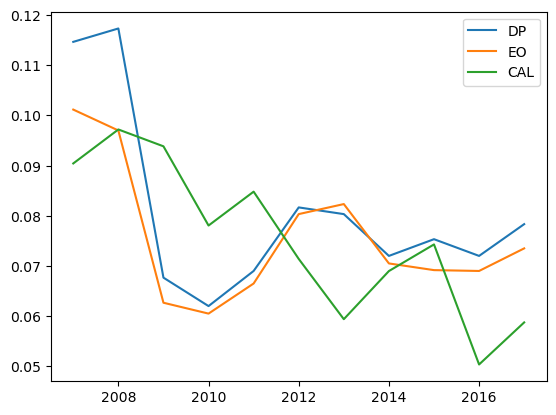

In [44]:
years = sorted(dp_by_year.keys())

plt.plot(years, [dp_by_year[y] for y in years], label="DP")
plt.plot(years, [eo_by_year[y] for y in years], label="EO")
plt.plot(years, [cal_by_year[y] for y in years], label="CAL")

plt.legend()
plt.show()

## 4. Confidence interval calculations

In [14]:
# DP

def dem_parity_calc_with_ci(df, attribute, z=1.96):
    dem_parity = (
        df
        .groupby(attribute)['predictions']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .round(4)
    )
    
    # Group sizes (needed for standard errors)
    group_counts = df.groupby(attribute)['predictions'].count()
    
    gaps = []
    lower_bounds = []
    upper_bounds = []
    
    ref = dict_references[attribute]
    p_ref = dem_parity.iloc[ref][1]
    n_ref = group_counts.iloc[ref]
    
    for i in range(len(dem_parity)):
        if i != ref:
            p_g = dem_parity.iloc[i][1]
            n_g = group_counts.iloc[i]
            
            gap = abs(p_g - p_ref)
            
            # Standard error of the difference between two proportions
            se = np.sqrt((p_ref * (1 - p_ref)) / n_ref + (p_g * (1 - p_g)) / n_g)
            
            gaps.append(gap)
            lower_bounds.append(max(0, gap - z * se))
            upper_bounds.append(min(1, gap + z * se))
    
    n_groups = len(dem_parity) - 1
    return (
        sum(gaps) / n_groups,
        sum(lower_bounds) / n_groups,
        sum(upper_bounds) / n_groups
    )


def dem_parity_total_with_ci(df):
    race_dp, race_lo, race_hi = dem_parity_calc_with_ci(df, "race")
    sex_dp, sex_lo, sex_hi = dem_parity_calc_with_ci(df, "sex")
    eth_dp, eth_lo, eth_hi = dem_parity_calc_with_ci(df, "ethnicity")
    
    A = len(dict_references)
    return (
        (race_dp + sex_dp + eth_dp) / A,
        (race_lo + sex_lo + eth_lo) / A,
        (race_hi + sex_hi + eth_hi) / A
    )

dp_point, dp_lower, dp_upper = {}, {}, {}

for year in range(2007, 2018):
    df_year = hmda[hmda['year'] == year]
    pt, lo, hi = dem_parity_total_with_ci(df_year)
    dp_point[year] = pt
    dp_lower[year] = lo
    dp_upper[year] = hi

In [15]:
# EO
def eq_odds_calc_with_ci(df, attribute, z=1.96):
    ref = dict_references[attribute]
    
    # TPR: among actually approved (y=1)
    df_approved = df[df['action_taken'] == 1]
    tpr = (
        df_approved
        .groupby(attribute)['predictions']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .round(4)
    )
    tpr_counts = df_approved.groupby(attribute)['predictions'].count()
    
    # FPR: among actually denied (y=0)
    df_denied = df[df['action_taken'] == 0]
    fpr = (
        df_denied
        .groupby(attribute)['predictions']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .round(4)
    )
    fpr_counts = df_denied.groupby(attribute)['predictions'].count()
    
    eo_values, lower_bounds, upper_bounds = [], [], []
    
    for i in range(len(tpr)):
        if i != ref:
            # TPR gap and its SE
            p_tpr_g = tpr.iloc[i][1]
            p_tpr_ref = tpr.iloc[ref][1]
            n_tpr_g = tpr_counts.iloc[i]
            n_tpr_ref = tpr_counts.iloc[ref]
            tpr_gap = abs(p_tpr_g - p_tpr_ref)
            se_tpr = np.sqrt(
                (p_tpr_ref * (1 - p_tpr_ref)) / n_tpr_ref +
                (p_tpr_g * (1 - p_tpr_g)) / n_tpr_g
            )
            
            # FPR gap and its SE
            p_fpr_g = fpr.iloc[i][1]
            p_fpr_ref = fpr.iloc[ref][1]
            n_fpr_g = fpr_counts.iloc[i]
            n_fpr_ref = fpr_counts.iloc[ref]
            fpr_gap = abs(p_fpr_g - p_fpr_ref)
            se_fpr = np.sqrt(
                (p_fpr_ref * (1 - p_fpr_ref)) / n_fpr_ref +
                (p_fpr_g * (1 - p_fpr_g)) / n_fpr_g
            )
            
            # EO for this subgroup is average of TPR and FPR gaps
            eo_gap = 0.5 * (tpr_gap + fpr_gap)
            eo_lo = 0.5 * (max(0, tpr_gap - z * se_tpr) + max(0, fpr_gap - z * se_fpr))
            eo_hi = 0.5 * (min(1, tpr_gap + z * se_tpr) + min(1, fpr_gap + z * se_fpr))
            
            eo_values.append(eo_gap)
            lower_bounds.append(eo_lo)
            upper_bounds.append(eo_hi)
    
    n_groups = len(tpr) - 1
    return (
        sum(eo_values) / n_groups,
        sum(lower_bounds) / n_groups,
        sum(upper_bounds) / n_groups
    )


def eq_odds_total_with_ci(df):
    race_eo, race_lo, race_hi = eq_odds_calc_with_ci(df, "race")
    sex_eo, sex_lo, sex_hi = eq_odds_calc_with_ci(df, "sex")
    eth_eo, eth_lo, eth_hi = eq_odds_calc_with_ci(df, "ethnicity")
    
    A = len(dict_references)
    return (
        (race_eo + sex_eo + eth_eo) / A,
        (race_lo + sex_lo + eth_lo) / A,
        (race_hi + sex_hi + eth_hi) / A
    )

eo_point, eo_lower, eo_upper = {}, {}, {}

for year in range(2007, 2018):
    df_year = hmda[hmda['year'] == year]
    pt, lo, hi = eq_odds_total_with_ci(df_year)
    eo_point[year] = pt
    eo_lower[year] = lo
    eo_upper[year] = hi

In [ ]:
# CAL

def calibration_calc_with_ci(df, attribute, B=10, z=1.96):
    ref = dict_references[attribute]
    
    df = df.copy()
    df['prob_bin'] = pd.cut(df['probabilities'], bins=B, labels=False)
    
    subgroups = sorted(df[attribute].unique())
    cal_values, lower_bounds, upper_bounds = [], [], []
    
    for i, group in enumerate(subgroups):
        if i != ref:
            bin_gaps, bin_los, bin_his = [], [], []
            
            for b in range(B):
                ref_bin = df[(df[attribute] == subgroups[ref]) & (df['prob_bin'] == b)]
                grp_bin = df[(df[attribute] == group) & (df['prob_bin'] == b)]
                
                n_ref = len(ref_bin)
                n_grp = len(grp_bin)
                
                p_ref = ref_bin['action_taken'].mean() if n_ref > 0 else 0
                p_grp = grp_bin['action_taken'].mean() if n_grp > 0 else 0
                
                gap = abs(p_grp - p_ref)
                
                # SE only meaningful if both bins have observations
                if n_ref > 0 and n_grp > 0:
                    se = np.sqrt(
                        (p_ref * (1 - p_ref)) / n_ref +
                        (p_grp * (1 - p_grp)) / n_grp
                    )
                    lo = max(0, gap - z * se)
                    hi = min(1, gap + z * se)
                else:
                    lo, hi = gap, gap  # no uncertainty estimate possible
                
                bin_gaps.append(gap)
                bin_los.append(lo)
                bin_his.append(hi)
            
            cal_values.append(sum(bin_gaps) / B)
            lower_bounds.append(sum(bin_los) / B)
            upper_bounds.append(sum(bin_his) / B)
    
    n_groups = len(subgroups) - 1
    return (
        sum(cal_values) / n_groups,
        sum(lower_bounds) / n_groups,
        sum(upper_bounds) / n_groups
    )


def calibration_total_with_ci(df, B=10):
    race_cal, race_lo, race_hi = calibration_calc_with_ci(df, "race", B)
    sex_cal, sex_lo, sex_hi = calibration_calc_with_ci(df, "sex", B)
    eth_cal, eth_lo, eth_hi = calibration_calc_with_ci(df, "ethnicity", B)
    
    A = len(dict_references)
    return (
        (race_cal + sex_cal + eth_cal) / A,
        (race_lo + sex_lo + eth_lo) / A,
        (race_hi + sex_hi + eth_hi) / A
    )

cal_point, cal_lower, cal_upper = {}, {}, {}

for year in range(2007, 2018):
    df_year = hmda[hmda['year'] == year]
    pt, lo, hi = calibration_total_with_ci(df_year,)
    cal_point[year] = pt
    cal_lower[year] = lo
    cal_upper[year] = hi

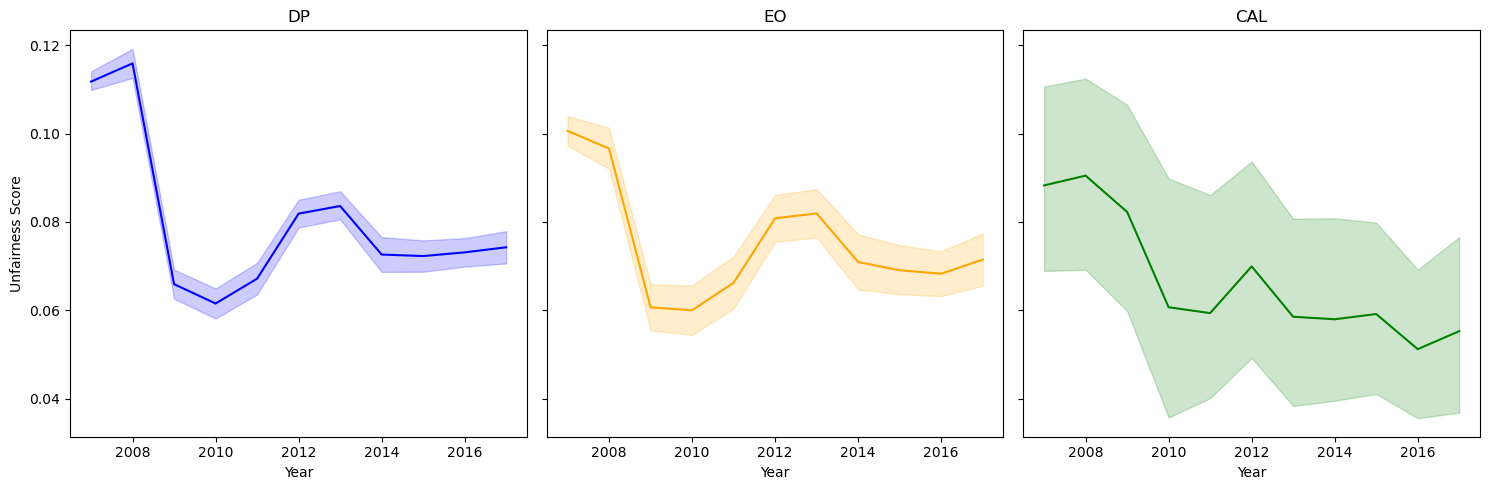

In [17]:
# Plot all three metrics

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

metrics = [
    ("DP", dp_point, dp_lower, dp_upper, "blue"),
    ("EO", eo_point, eo_lower, eo_upper, "orange"),
    ("CAL", cal_point, cal_lower, cal_upper, "green"),
]

for ax, (label, point, lower, upper, colour) in zip(axes, metrics):
    years = sorted(point.keys())
    pts = [point[y] for y in years]
    lows = [lower[y] for y in years]
    highs = [upper[y] for y in years]
    
    ax.plot(years, pts, label=label, color=colour)
    ax.fill_between(years, lows, highs, alpha=0.2, color=colour)
    ax.set_title(label)
    ax.set_xlabel("Year")

axes[0].set_ylabel("Unfairness Score")
plt.tight_layout()
plt.show()

In [ ]:
# Check why CAL has wide CI bands

def bin_counts(df, attribute, B=10):
    df = df.copy()
    df['prob_bin'] = pd.cut(df['probabilities'], bins=B, labels=False)
    return df.groupby([attribute, 'prob_bin']).size().unstack(fill_value=0)

# Example for one year
df_2007 = hmda[hmda['year'] == 2007]
print(bin_counts(df_2007, 'ethnicity'))
print(bin_counts(df_2007, 'sex'))
print(bin_counts(df_2007, 'race'))

prob_bin      0       1       2       3     4
ethnicity                                    
1.0        1862  126814  460225   31030   577
2.0        2226  115953  944240  169898  2587
99.0       1400   47026  281652   43436  1062
prob_bin     0       1        2       3     4
sex                                          
1.0       2326  163470  1035246  164420  2705
2.0       2165  103159   525031   57104   854
99.0       997   23164   125840   22840   667
prob_bin     0       1        2       3     4
race                                         
1.0        519   15148    36513    3188    57
2.0        351   21159   172695   23867   249
3.0        450   23716    88181    7786   149
4.0        126    4726    25035    2386    43
5.0       2377  167033  1046248  160943  2605
99.0      1665   58011   317445   46194  1123


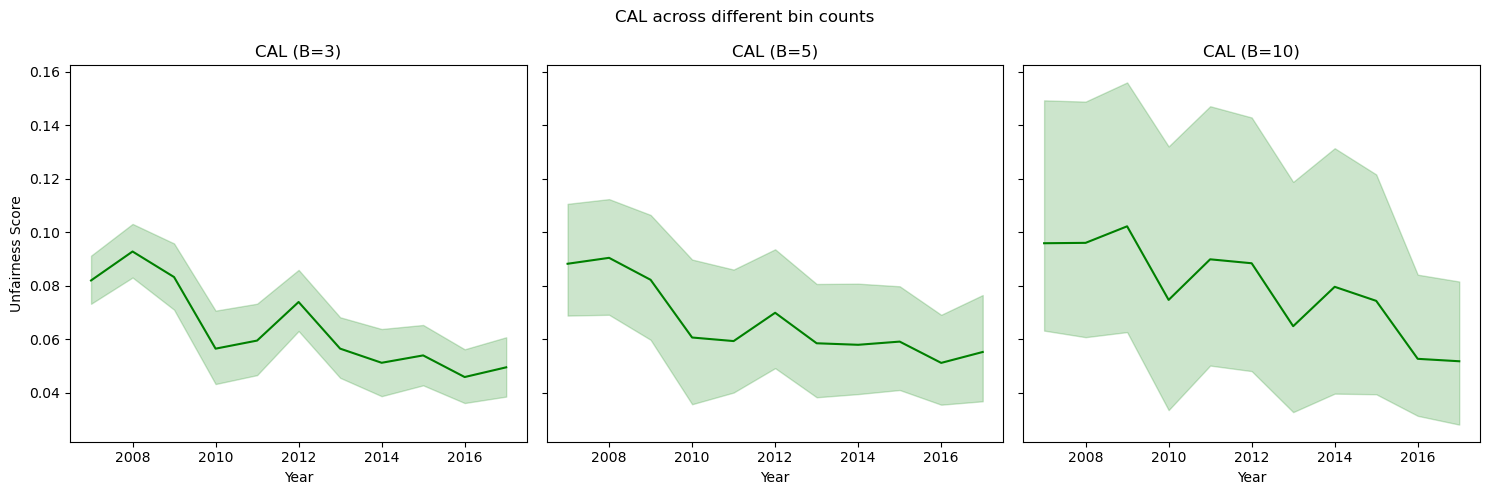

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, B in zip(axes, [3, 5, 10]):
    cal_point, cal_lower, cal_upper = {}, {}, {}
    
    for year in range(2007, 2018):
        df_year = hmda[hmda['year'] == year]
        pt, lo, hi = calibration_total_with_ci(df_year, B=B)
        cal_point[year] = pt
        cal_lower[year] = lo
        cal_upper[year] = hi
    
    years = sorted(cal_point.keys())
    pts = [cal_point[y] for y in years]
    lows = [cal_lower[y] for y in years]
    highs = [cal_upper[y] for y in years]
    
    ax.plot(years, pts, color="green")
    ax.fill_between(years, lows, highs, alpha=0.2, color="green")
    ax.set_title(f"CAL (B={B})")
    ax.set_xlabel("Year")

axes[0].set_ylabel("Unfairness Score")
plt.suptitle("CAL across different bin counts")
plt.tight_layout()
plt.show()